# 4. Relationship Testing

In this section, I perform five statistical relationship tests aligned with the research questions and hypotheses outlined in the project objectives. Each test is designed to provide insights into factors influencing taxi revenues, tipping behaviors, and trip characteristics. I also ensure that all requirements are met, including assumption checks, the use of parametric and non-parametric tests as needed, and the inclusion of a factorial ANOVA.

### 4.1 Overview of Testing Process
---

**Assumption Checks:** For each test, I will first check assumptions such as normality and homogeneity of variance.

**Parametric Tests:** If assumptions are met, a parametric test will be performed.

**Non-Parametric Alternatives:** If assumptions are violated, a non-parametric test will be applied.

**Factorial ANOVA:** At least one test will involve a factorial ANOVA to explore interactions between multiple factors.

**Omnibus and Pairwise Tests:** Omnibus tests will be followed by pairwise comparisons if significant differences are found.


### 4.2 Relationship Tests

---

**Test 1: Trip Distance and Fare Amount**

* Research Question: Is there a correlation between trip distance and fare amounts?
  
* Hypothesis (H1): Longer trip distances result in higher fares due to distance-based pricing.
  
**Test Performed:**

* Assumption Checks: Normality (Shapiro-Wilk test) and linearity (scatterplot).

**Test Used:**

* Parametric: Pearson Correlation (if assumptions are met).
  
* Non-Parametric: Spearman Correlation (if assumptions are violated).
  
**Visualization:** Scatterplot of trip_distance vs. fare_amount with a regression line overlay.
  
**Purpose:** To establish whether trip distance is a primary determinant of fare.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, pearsonr, spearmanr, kstest, probplot

# Load Dataset
df=pd.read_csv('preprocessed_data.csv')

Since the dataset consist of more than 5000 rows so, Shapiro-Wilk test is not suitable. I will use Kolmogorov-Smirnov Test.

In [29]:
# Kolmogorov-Smirnov test
stat, p = kstest(df['trip_distance'], 'norm')
print('Kolmogorov-Smirnov Test: Statistics=%.3f, p=%.3f' % (stat, p))

Kolmogorov-Smirnov Test: Statistics=0.646, p=0.000


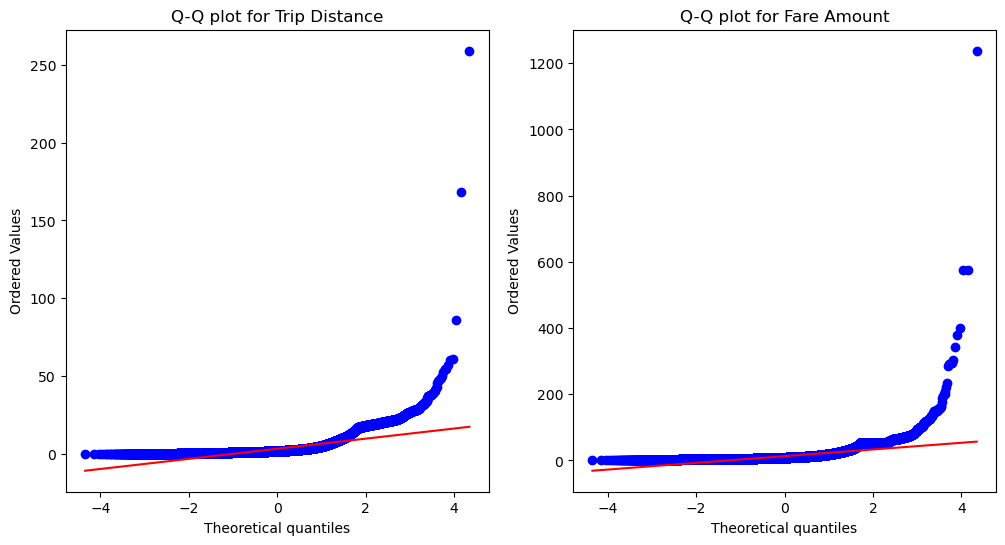

In [37]:
# Step 2: Visualize the distribution (Q-Q plot for normality check)
plt.figure(figsize=(12, 6))

# Q-Q plot for Trip Distance
plt.subplot(1, 2, 1)
probplot(df['trip_distance'], dist="norm", plot=plt)
plt.title('Q-Q plot for Trip Distance')

# Q-Q plot for Fare Amount
plt.subplot(1, 2, 2)
probplot(df['fare_amount'], dist="norm", plot=plt)
plt.title('Q-Q plot for Fare Amount')

plt.show()

**Interpretation:**

The Kolmogorov-Smirnov (K-S) test result shows that the p-value is 0.000, which indicates that the data is not normally distributed. A p-value less than 0.05 (in this case, 0.000) suggests that we reject the null hypothesis of the K-S test, meaning the distribution of the data significantly differs from a normal distribution.

The K-S test suggests that both trip_distance and fare_amount are not normally distributed, so let's proceed with non-parametric tests(Spearman's rank correlation).

In [56]:
# Non-parametric Correlation Test (Spearman's rank correlation)
correlation, p_value = spearmanr(df['trip_distance'], df['fare_amount'])
print(f"Spearman Correlation: {correlation}, p-value: {p_value}")

Spearman Correlation: 0.9127195067162954, p-value: 0.0


**Interpretation:**

* Correlation of 0.913 indicates a strong positive monotonic relationship between trip_distance and fare_amount. This means that as the trip distance increases, the fare amount tends to increase as well. The correlation is quite strong, suggesting that trip distance is a primary factor influencing the fare amount.

* p-value of 0.0 means that the correlation is statistically significant. Since the p-value is far below the typical significance level of 0.05, we can reject the null hypothesis (which states that there is no relationship between the variables). This confirms that the relationship between trip_distance and fare_amount is not due to random chance.

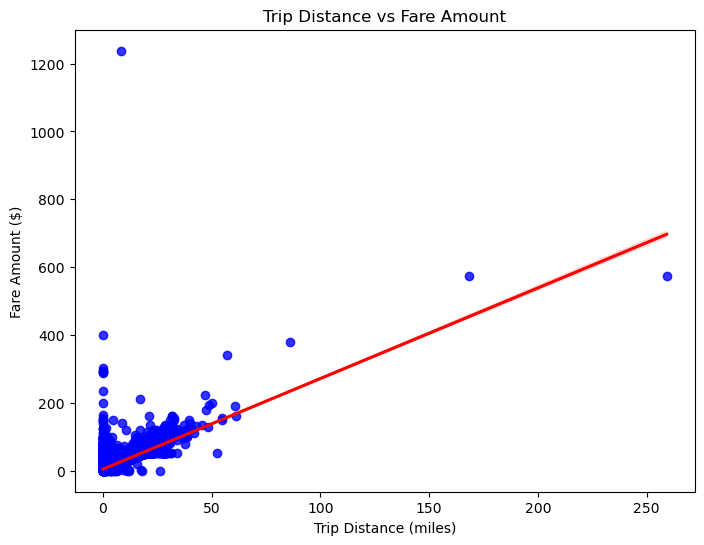

In [59]:
# Step 3: Visualization (Scatterplot with regression line)
plt.figure(figsize=(8, 6))
sns.regplot(x='trip_distance', y='fare_amount', data=df, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()

---

**Test 2: Passenger Count and Fare/Tipping Behavior**

* Research Question: How does passenger count affect fares and tipping behavior?
  
* Hypothesis (H2): Trips with more passengers have higher fares and may influence tipping behaviors differently.
  
**Test Performed:**

* Assumption Checks: Homogeneity of variance (Levene's test) and normality (Q-Q plot).
  
**Test Used:**

* Parametric: ANOVA to compare fare_amount and tip_amount across passenger count categories.
  
* Non-Parametric: Kruskal-Wallis test if assumptions are violated.
  
* Follow-up Pairwise Comparisons: Dunn’s test for pairwise comparisons, with p-values adjusted using the Bonferroni correction or other appropriate methods.
  
**Visualization:** Boxplots of fare_amount and tip_amount grouped by passenger_count.
  
**Purpose:** To determine if group trips generate higher revenues or exhibit different tipping patterns.

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, kruskal, probplot
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

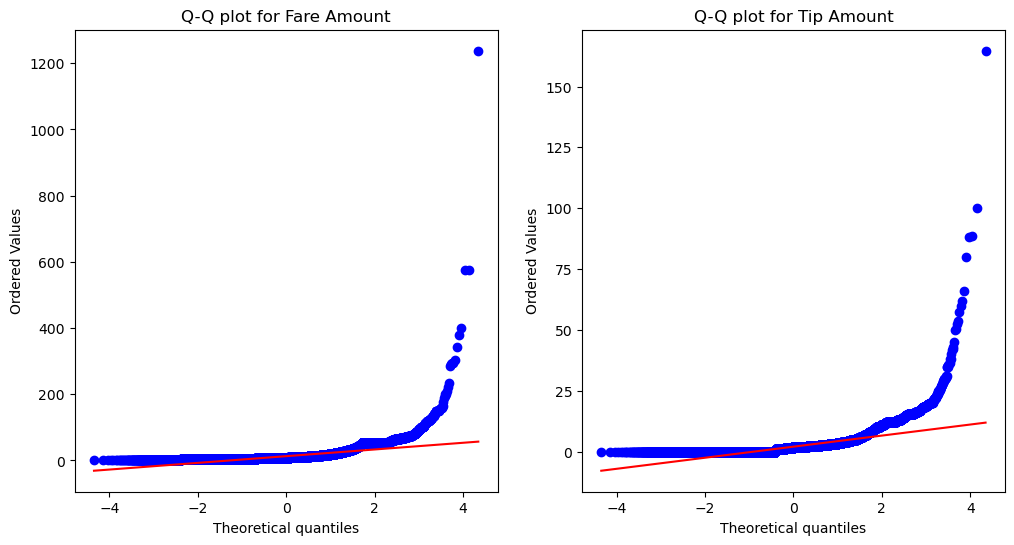

Levene's Test for Fare Amount: stat=13.056167963071603, p-value=6.521914909104362e-17
Levene's Test for Tip Amount: stat=8.760612664292742, p-value=8.272943564197507e-11


In [71]:
# Step 1: Assumption Check

plt.figure(figsize=(12, 6))
# Q-Q plot for Fare Amount
plt.subplot(1, 2, 1)
probplot(df['fare_amount'], dist="norm", plot=plt)
plt.title('Q-Q plot for Fare Amount')

# Q-Q plot for Tip Amount
plt.subplot(1, 2, 2)
probplot(df['tip_amount'], dist="norm", plot=plt)
plt.title('Q-Q plot for Tip Amount')
plt.show()

# Levene's test for homogeneity of variance for 'fare_amount' and 'tip_amount' across 'passenger_count'
groups_fare = [df[df['passenger_count'] == i]['fare_amount'] for i in df['passenger_count'].unique()]
groups_tip = [df[df['passenger_count'] == i]['tip_amount'] for i in df['passenger_count'].unique()]

# Levene's test for 'fare_amount'
levene_fare_stat, levene_fare_p = levene(*groups_fare)

# Levene's test for 'tip_amount'
levene_tip_stat, levene_tip_p = levene(*groups_tip)

print(f"Levene's Test for Fare Amount: stat={levene_fare_stat}, p-value={levene_fare_p}")
print(f"Levene's Test for Tip Amount: stat={levene_tip_stat}, p-value={levene_tip_p}")

**Interpretation:**

Levene's Test for Fare Amount:

* p-value = 6.52e-17, which is much smaller than the 0.05 significance level, meaning that the variances are not equal across groups of passenger_count.

Levene's Test for Tip Amount:

* p-value = 8.27e-11, which also suggests that the variances are not equal for tip_amount across passenger_count groups.

Since the variances are not equal (p-value < 0.05 for both tests), we cannot use ANOVA because it assumes homogeneity of variance. Instead, we will proceed with the Kruskal-Wallis test (a non-parametric test) to compare the groups for both fare_amount and tip_amount.

In [81]:
# Step 2: Kruskal-Wallis Test for 'fare_amount' across 'passenger_count'
groups_fare = [df[df['passenger_count'] == i]['fare_amount'] for i in df['passenger_count'].unique()]
fare_kw_stat, fare_kw_p = kruskal(*groups_fare)
print(f"Kruskal-Wallis Test for Fare Amount: stat={fare_kw_stat}, p-value={fare_kw_p}")

# Kruskal-Wallis Test for 'tip_amount' across 'passenger_count'
groups_tip = [df[df['passenger_count'] == i]['tip_amount'] for i in df['passenger_count'].unique()]
tip_kw_stat, tip_kw_p = kruskal(*groups_tip)
print(f"Kruskal-Wallis Test for Tip Amount: stat={tip_kw_stat}, p-value={tip_kw_p}")

Kruskal-Wallis Test for Fare Amount: stat=175.93331547855553, p-value=1.4065694595934473e-34
Kruskal-Wallis Test for Tip Amount: stat=76.52023843752501, p-value=7.041684653025125e-14


**Interpretation:**

Since the p-value is much less than 0.05, we reject the null hypothesis and conclude that there are significant differences in fare_amount across different passenger_count groups.

Similarly, the p-value is also much less than 0.05, meaning we reject the null hypothesis and conclude that there are significant differences in tip_amount across different passenger_count groups.

Since both Kruskal-Wallis tests were significant, we now need to perform Dunn's Test for pairwise comparisons to identify which specific passenger_count groups differ for both fare_amount and tip_amount.

In [85]:
# For Fare Amount - Performing Dunn's Test for Pairwise Comparisons
if fare_kw_p < 0.05:
    print("Performing Pairwise Dunn's Test for Fare Amount:")
    dunn_fare = sp.posthoc_dunn(df, val_col='fare_amount', group_col='passenger_count')
    print(dunn_fare)

# For Tip Amount - Performing Dunn's Test for Pairwise Comparisons
if tip_kw_p < 0.05:
    print("Performing Pairwise Dunn's Test for Tip Amount:")
    dunn_tip = sp.posthoc_dunn(df, val_col='tip_amount', group_col='passenger_count')
    print(dunn_tip)


Performing Pairwise Dunn's Test for Fare Amount:
              0             1             2             3             4  \
0  1.000000e+00  1.876228e-01  3.259392e-05  1.229879e-05  6.442791e-12   
1  1.876228e-01  1.000000e+00  5.890026e-17  1.537122e-09  6.900520e-20   
2  3.259392e-05  5.890026e-17  1.000000e+00  2.816656e-01  2.955998e-07   
3  1.229879e-05  1.537122e-09  2.816656e-01  1.000000e+00  2.275398e-04   
4  6.442791e-12  6.900520e-20  2.955998e-07  2.275398e-04  1.000000e+00   
5  2.036974e-01  7.654844e-01  2.289251e-04  1.075980e-04  7.582834e-12   
6  8.174850e-02  2.703842e-01  3.506166e-02  1.102050e-02  8.836420e-08   
9  1.410288e-02  1.591436e-02  2.099023e-02  2.243857e-02  3.098165e-02   

              5             6         9  
0  2.036974e-01  8.174850e-02  0.014103  
1  7.654844e-01  2.703842e-01  0.015914  
2  2.289251e-04  3.506166e-02  0.020990  
3  1.075980e-04  1.102050e-02  0.022439  
4  7.582834e-12  8.836420e-08  0.030982  
5  1.000000e+00  4.8299

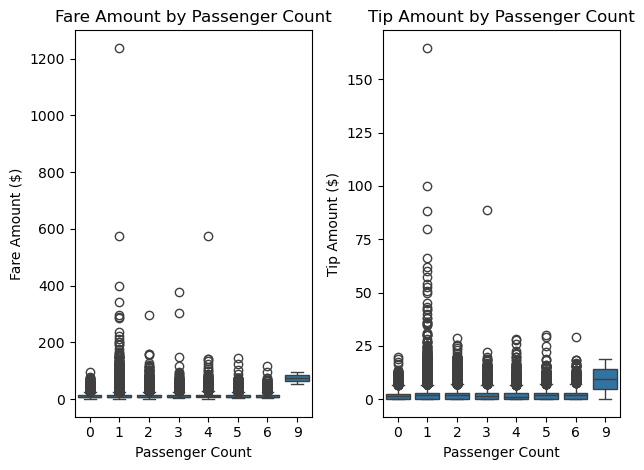

In [90]:
# Boxplot for 'fare_amount' grouped by 'passenger_count'
plt.subplot(1, 2, 1)
sns.boxplot(x='passenger_count', y='fare_amount', data=df)
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')

# Boxplot for 'tip_amount' grouped by 'passenger_count'
plt.subplot(1, 2, 2)
sns.boxplot(x='passenger_count', y='tip_amount', data=df)
plt.title('Tip Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Tip Amount ($)')

plt.tight_layout()
plt.show()

**Interpretation**

**Fare Amount:**

The Kruskal-Wallis test revealed significant differences in fare_amount across passenger_count groups (p-value < 0.05). Dunn’s post-hoc test identified the following key findings:

Group 0 (fewer passengers) has significantly lower fares compared to Groups 2, 3, and 4 (more passengers).
Group 1 does not show significant differences with Group 0 but differs from Group 2.

Significant differences suggest that longer or more complex trips (more passengers) tend to result in higher fare amounts.

**Tip Amount:**

The Kruskal-Wallis test showed significant differences in tip_amount across passenger_count groups (p-value < 0.05). Dunn’s test for pairwise comparisons revealed:

Significant differences in tip amounts between Groups 0, 1, 2, 4, and 5, where larger groups (more passengers) generally tend to provide higher tips.
Group 3 showed fewer significant differences with other groups, suggesting tip behavior may be less influenced by the number of passengers in some cases.

**Key Insights:**

**Fare Amount:** Higher passenger counts are associated with higher fare amounts, reflecting longer or more complex trips.

**Tip Amount:** Larger groups tend to leave larger tips, likely due to the increased fare amounts or group-based tipping behavior.

These findings suggest that both passenger count and trip complexity play a significant role in determining both fares and tips.


---


**Test 3: Payment Type and Tip Amount**

* Research Question: How do different payment methods affect tipping behaviors
  
* Hypothesis (H3): Credit card payments show higher tips due to convenience features.
  
**Test Performed:**

* Assumption Checks: Homogeneity of variance (Levene's test) and normality.
Test Used:

* Parametric: ANOVA for differences in tip_amount by payment_type.
  
* Non-Parametric: Kruskal-Wallis test if assumptions are violated.
  
**Visualization:** Boxplot of tip_amount by payment_type.
  
**Purpose:** To understand how payment methods influence passenger tipping.


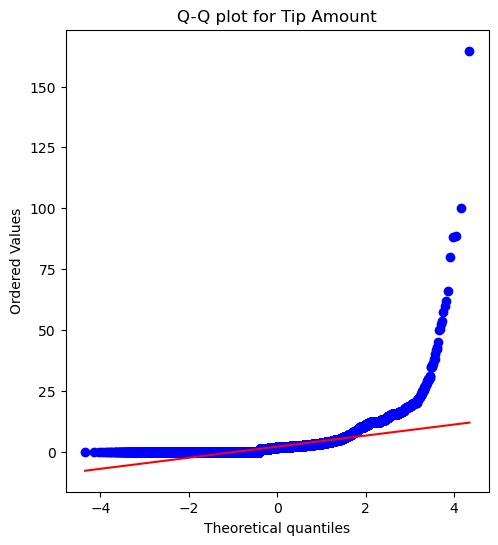

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, shapiro, f_oneway, kruskal, probplot
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

# Step 1: Assumption Check - Normality (Q-Q plot) and Homogeneity of Variance (Levene's test)
plt.figure(figsize=(12, 6))

# Q-Q plot for Tip Amount
plt.subplot(1, 2, 1)
probplot(df['tip_amount'], dist="norm", plot=plt)
plt.title('Q-Q plot for Tip Amount')

plt.show()

In [94]:
# Levene's test for homogeneity of variances across 'payment_type' groups
# Grouping by 'payment_type' for 'tip_amount'
groups_tip = [df[df['payment_type'] == i]['tip_amount'] for i in df['payment_type'].unique()]

# Levene's test for 'tip_amount'
levene_stat, levene_p = levene(*groups_tip)
print(f"Levene's Test for Tip Amount: stat={levene_stat}, p-value={levene_p}")

Levene's Test for Tip Amount: stat=3601.056603174989, p-value=0.0


**Interpretation:**

Since the p-value is 0.0 (much smaller than 0.05), we reject the null hypothesis that the variances are equal across the groups defined by payment_type.

This indicates that the assumption of homogeneity of variance is violated, and therefore, we cannot use ANOVA for this analysis.

Since Levene's Test suggests unequal variances, we should proceed with the Kruskal-Wallis test (a non-parametric alternative to ANOVA) for comparing tip_amount across different payment_type categories.

In [98]:
# Step 2: Performing Kruskal-Wallis Test for 'tip_amount' across 'payment_type'
groups_tip = [df[df['payment_type'] == i]['tip_amount'] for i in df['payment_type'].unique()]
kw_stat, kw_p = kruskal(*groups_tip)
print(f"Kruskal-Wallis for Tip Amount: stat={kw_stat}, p-value={kw_p}")

Kruskal-Wallis for Tip Amount: stat=62200.44295886349, p-value=0.0


**Interpretation:**

Since the Kruskal-Wallis test is significant, we now need to perform pairwise comparisons to identify which specific payment_type groups differ in terms of tip_amount.

We can proceed with Dunn's test for pairwise comparisons.

Performing Pairwise Dunn's Test for Tip Amount:
               1         2              3              4
1   1.000000e+00  0.000000  3.749555e-281  1.521869e-109
2   0.000000e+00  1.000000   8.370804e-01   9.988317e-01
3  3.749555e-281  0.837080   1.000000e+00   9.125224e-01
4  1.521869e-109  0.998832   9.125224e-01   1.000000e+00


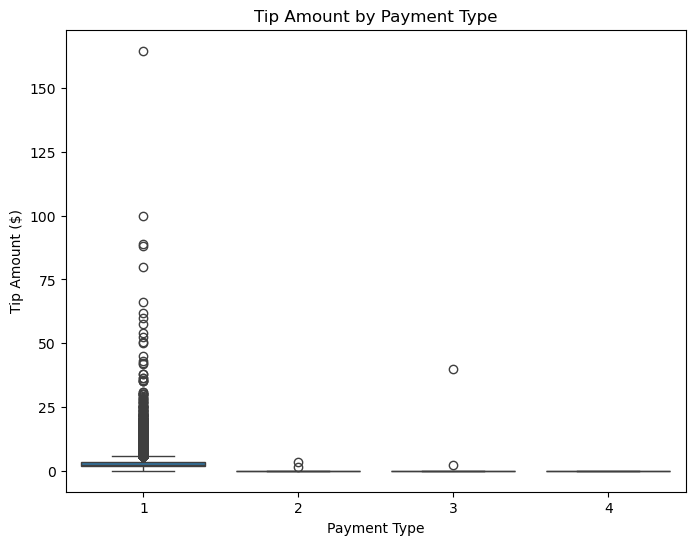

In [101]:
# Performing Pairwise Dunn's Test for Tip Amount (since Kruskal-Wallis was significant)
print("Performing Pairwise Dunn's Test for Tip Amount:")
dunn = sp.posthoc_dunn(df, val_col='tip_amount', group_col='payment_type')
print(dunn)

# Step 4: Visualization (Boxplots to compare 'tip_amount' across 'payment_type')
plt.figure(figsize=(8, 6))
sns.boxplot(x='payment_type', y='tip_amount', data=df)
plt.title('Tip Amount by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Tip Amount ($)')
plt.show()


**Interpretation:**

* Group 1 (likely credit card payments) shows highly significant differences in tip amounts when compared to Groups 2, 3, and 4 (likely other payment methods such as cash, etc.).

* Groups 2, 3, and 4 do not show significant differences between each other (p-values > 0.05), indicating that the tip amounts are not significantly different across these payment types.

* Group 1 (likely credit card payments) tends to have higher tip amounts, which aligns with the hypothesis that credit card payments may involve more convenient tipping features (such as preset tip percentages).

Thus, credit card payments are associated with higher tips.

**Test 4: Time of Day and Trip Duration/Fare**

* Research Question: Are trip durations and fare amounts affected by the time of day?
  
* Hypothesis (H4): Nighttime rides have higher fares due to surcharges, while peak times increase trip durations.
  
**Test Performed:**

* Assumption Checks: Normality and homogeneity of variance.
  
**Test Used:**

* Factorial ANOVA: Analyze interaction effects between hour_of_day and payment_type on trip_duration and fare_amount.
  
* Follow-up Pairwise Comparisons: If significant, pairwise comparisons between hours.
  
**Visualization:** Interaction plots showing fare_amount and trip_duration by hour_of_day and payment_type.
  
**Purpose:** To assess temporal patterns in trip durations and revenues.
  

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, shapiro, f_oneway, kruskal, probplot
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

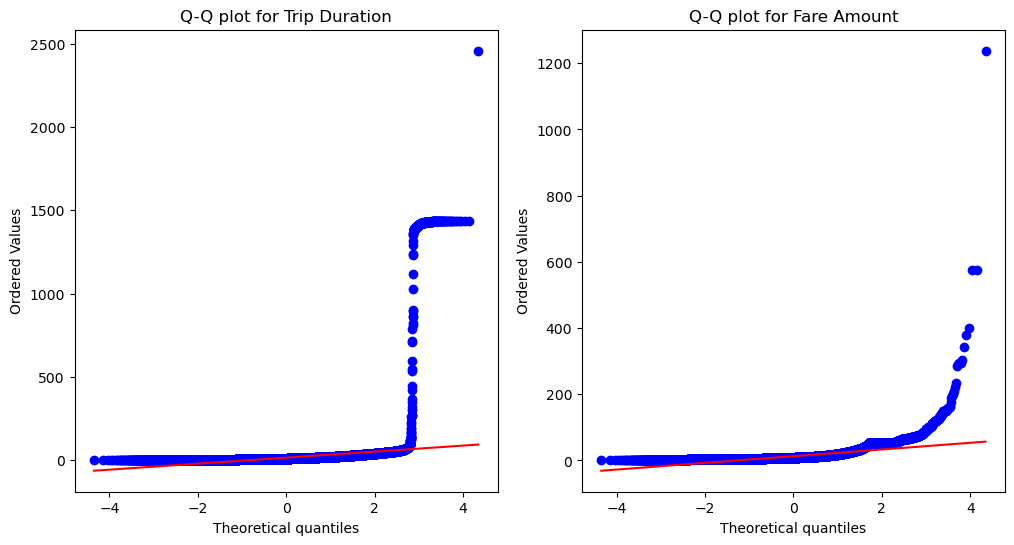

In [110]:
# Step 1: Assumption Check - Normality (Q-Q plot) and Homogeneity of Variance (Levene's test)
plt.figure(figsize=(12, 6))

# Q-Q plot for Trip Duration
plt.subplot(1, 2, 1)
probplot(df['trip_duration'], dist="norm", plot=plt)
plt.title('Q-Q plot for Trip Duration')

# Q-Q plot for Fare Amount
plt.subplot(1, 2, 2)
probplot(df['fare_amount'], dist="norm", plot=plt)
plt.title('Q-Q plot for Fare Amount')

plt.show()

In [112]:
# Levene's test for homogeneity of variances across 'hour_of_day' groups for 'trip_duration' and 'fare_amount'
groups_trip_duration = [df[df['hour_of_day'] == i]['trip_duration'] for i in df['hour_of_day'].unique()]
groups_fare_amount = [df[df['hour_of_day'] == i]['fare_amount'] for i in df['hour_of_day'].unique()]

# Levene's test for 'trip_duration'
levene_trip_duration_stat, levene_trip_duration_p = levene(*groups_trip_duration)

# Levene's test for 'fare_amount'
levene_fare_stat, levene_fare_p = levene(*groups_fare_amount)

print(f"Levene's Test for Trip Duration: stat={levene_trip_duration_stat}, p-value={levene_trip_duration_p}")
print(f"Levene's Test for Fare Amount: stat={levene_fare_stat}, p-value={levene_fare_p}")

Levene's Test for Trip Duration: stat=2.203633432032507, p-value=0.0007505545317223007
Levene's Test for Fare Amount: stat=16.031042170829632, p-value=6.389680203874048e-64


**Interpretation:**

Since the p-value is less than 0.05, we reject the null hypothesis and conclude that the variances are not equal across the hour_of_day groups for trip_duration.

Similarly, the p-value is much smaller than 0.05, indicating that the variances are not equal across hour_of_day groups for fare_amount.

In [116]:
# Step 2: Perform Kruskal-Wallis Test for 'trip_duration' and 'fare_amount' across 'hour_of_day'
# Grouping by 'hour_of_day' for trip_duration
groups_trip_duration = [df[df['hour_of_day'] == i]['trip_duration'] for i in df['hour_of_day'].unique()]
kw_trip_duration_stat, kw_trip_duration_p = kruskal(*groups_trip_duration)
print(f"Kruskal-Wallis Test for Trip Duration: stat={kw_trip_duration_stat}, p-value={kw_trip_duration_p}")

# Grouping by 'hour_of_day' for fare_amount
groups_fare_amount = [df[df['hour_of_day'] == i]['fare_amount'] for i in df['hour_of_day'].unique()]
kw_fare_stat, kw_fare_p = kruskal(*groups_fare_amount)
print(f"Kruskal-Wallis Test for Fare Amount: stat={kw_fare_stat}, p-value={kw_fare_p}")

Kruskal-Wallis Test for Trip Duration: stat=458.8306843878676, p-value=1.2515400126868497e-82
Kruskal-Wallis Test for Fare Amount: stat=399.1395536214733, p-value=2.671547415927241e-70


**Interpretation:**

Since the p-value is extremely small (much less than 0.05), we reject the null hypothesis. This indicates that there are significant differences in trip_duration across the different hour_of_day groups.

Similarly, the p-value for fare_amount is also extremely small (much less than 0.05), meaning that we reject the null hypothesis. This suggests that there are significant differences in fare_amount across the different hour_of_day groups.

**Implications:**

The Kruskal-Wallis test, a non-parametric alternative to ANOVA, was applied due to violations of normality and homogeneity of variance, as seen from the Q-Q plots and Levene's test. These results confirm that there are significant differences in both trip duration and fare amount across the grouping variable(s) under study.

In [120]:
# Step 3: Pairwise Comparisons if Kruskal-Wallis is significant
# For Trip Duration if Kruskal-Wallis is significant
if kw_trip_duration_p < 0.05:
    print("Performing Pairwise Dunn's Test for Trip Duration:")
    dunn_trip_duration = sp.posthoc_dunn(df, val_col='trip_duration', group_col='hour_of_day')
    print(dunn_trip_duration)

# For Fare Amount if Kruskal-Wallis is significant
if kw_fare_p < 0.05:
    print("Performing Pairwise Dunn's Test for Fare Amount:")
    dunn_fare_amount = sp.posthoc_dunn(df, val_col='fare_amount', group_col='hour_of_day')
    print(dunn_fare_amount)


Performing Pairwise Dunn's Test for Trip Duration:
              0             1             2             3             4   \
0   1.000000e+00  9.966842e-01  2.424249e-02  2.741982e-03  9.161400e-03   
1   9.966842e-01  1.000000e+00  3.019957e-02  3.705555e-03  1.099576e-02   
2   2.424249e-02  3.019957e-02  1.000000e+00  3.625604e-01  4.358356e-01   
3   2.741982e-03  3.705555e-03  3.625604e-01  1.000000e+00  9.723006e-01   
4   9.161400e-03  1.099576e-02  4.358356e-01  9.723006e-01  1.000000e+00   
5   2.060282e-04  2.879847e-04  5.973834e-02  3.055343e-01  3.265092e-01   
6   1.760384e-16  1.964807e-15  1.891463e-08  1.932526e-05  9.911647e-05   
7   6.080337e-12  4.961903e-11  5.287900e-05  7.169599e-03  1.522221e-02   
8   3.014375e-06  8.512652e-06  4.884711e-02  4.264571e-01  4.577498e-01   
9   2.650980e-06  8.104888e-06  5.705306e-02  4.813522e-01  5.095276e-01   
10  5.278576e-08  2.441204e-07  1.156414e-02  2.136812e-01  2.575038e-01   
11  3.174042e-08  1.664636e-07  1.139

**Interpretation:**

For Trip Duration: Significant differences in trip_duration are found across several hours of the day, particularly between early morning hours (0-4 hours) and late afternoon hours (5-8 hours).

For Fare Amount: Significant differences in fare_amount were observed in several hours where longer trips or higher fare charges might correlate with surcharges during specific times of the day (e.g., late hours).

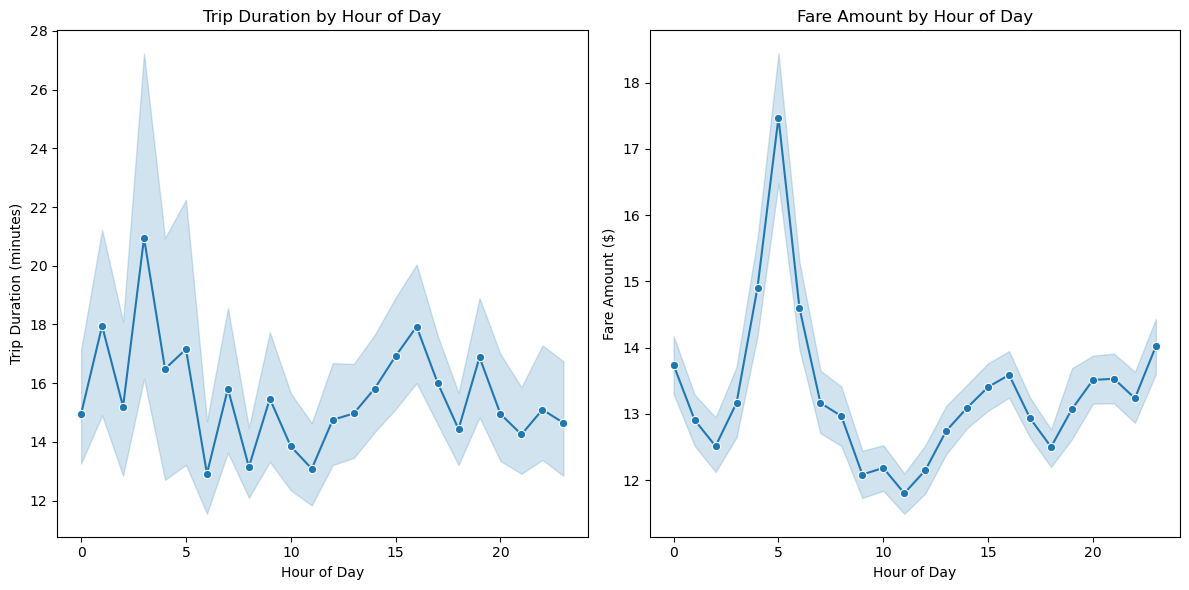

In [122]:
# Step 4: Visualization (Interaction plots)
plt.figure(figsize=(12, 6))

# Interaction plot for trip_duration by hour_of_day
plt.subplot(1, 2, 1)
sns.lineplot(x='hour_of_day', y='trip_duration', data=df, marker='o')
plt.title('Trip Duration by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Trip Duration (minutes)')

# Interaction plot for fare_amount by hour_of_day
plt.subplot(1, 2, 2)
sns.lineplot(x='hour_of_day', y='fare_amount', data=df, marker='o')
plt.title('Fare Amount by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fare Amount ($)')

plt.tight_layout()
plt.show()

---

**Test 5: Congestion Surcharges and Total Fare Amount**

* Research Question: How do congestion surcharges impact overall fares?
  
* Hypothesis (H5): Higher congestion surcharges lead to increased total fares, regardless of trip distance.
  
**Test Performed:**

* Assumption Checks: Normality and homogeneity of variance for the parametric test.
  
**Test Used:**

* Parametric: One-way ANOVA to compare total_amount across levels of congestion_surcharge.
  
* Non-Parametric: Kruskal-Wallis test if assumptions are violated.

* Follow-up Pairwise Comparisons: Tukey’s HSD or Dunn’s test to identify significant differences between surcharge levels.

**Visualization:** Boxplots of total_amount grouped by congestion_surcharge.
  
**Purpose:** To evaluate how congestion surcharges influence overall fares.
  

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, kruskal
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as spb

Surcharge Level: 2.5
Subset Size: 90393
Subset Values: [10.56 11.3  13.39 ...  9.54 11.75 17.3 ]
Surcharge Level: 0.0
Subset Size: 9249
Subset Values: [45.8  10.8  64.56 ... 26.8   6.3   9.8 ]
Surcharge Level: 0.75
Subset Size: 2
Subset Values: [ 7.26 13.05]
Surcharge Level: 2.75
Subset Size: 1
Subset Values: [19.86]
Skipping Surcharge Level 2.75 due to insufficient data or lack of variability.


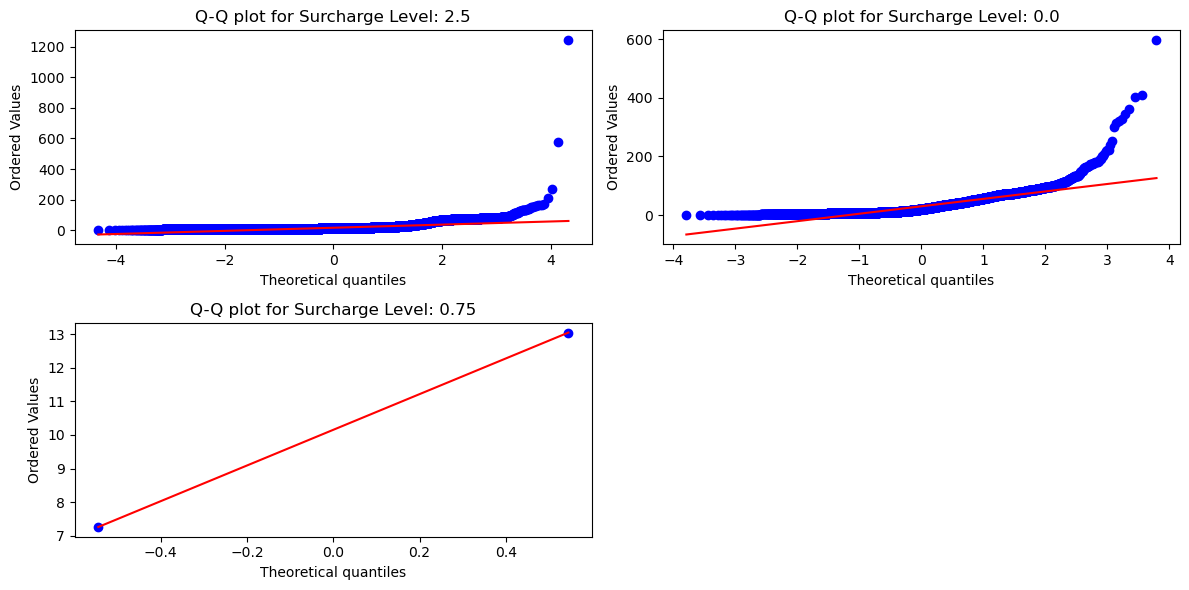

In [90]:
# Q-Q plot for total_amount grouped by congestion_surcharge
plt.figure(figsize=(12, 6))

# Q-Q plot for each congestion_surcharge level
for i, surcharge in enumerate(df['congestion_surcharge'].unique(), start=1):
    subset = df[df['congestion_surcharge'] == surcharge]['total_amount']
    subset = subset.dropna()  # Remove NaN values
    
    # Debugging prints
    print(f"Surcharge Level: {surcharge}")
    print(f"Subset Size: {len(subset)}")
    print(f"Subset Values: {subset.values}")
    
    if len(subset) > 1 and subset.nunique() > 1:  # Ensure enough data points and variability
        plt.subplot(2, 2, i)
        probplot(subset, dist="norm", plot=plt)
        plt.title(f'Q-Q plot for Surcharge Level: {surcharge}')
    else:
        print(f"Skipping Surcharge Level {surcharge} due to insufficient data or lack of variability.")

plt.tight_layout()
plt.show()

In [131]:
# Levene's Test for Homogeneity of Variance across different surcharge levels
stat, p = levene(*[df[df['congestion_surcharge'] == level]['total_amount'] for level in df['congestion_surcharge'].unique()])
print(f"Levene's Test for Homogeneity of Variance: stat={stat}, p-value={p}")

Levene's Test for Homogeneity of Variance: stat=2690.4246302482675, p-value=0.0


**Interpretation:**

A p-value of 0.0 means the null hypothesis is rejected, indicating that the variances across the levels of congestion_surcharge are not equal. This violates the assumption of homogeneity of variance, which is required for parametric tests like ANOVA.

Since the assumption of equal variances is violated, we should proceed with a non-parametric test. In this case, we can use the Kruskal-Wallis test, which is the appropriate non-parametric alternative to ANOVA when the assumption of homogeneity of variance is not met.

In [135]:
# Kruskal-Wallis test for total_amount by congestion_surcharge levels
from scipy.stats import kruskal

# Perform Kruskal-Wallis test
stat, p = kruskal(*[df[df['congestion_surcharge'] == level]['total_amount'] for level in df['congestion_surcharge'].unique()])
print(f"Kruskal-Wallis Test: stat={stat}, p-value={p}")

Kruskal-Wallis Test: stat=717.5162175177234, p-value=3.3403576178135956e-155


**Interpretation:**

The p-value is extremely small (much smaller than the typical threshold of 0.05), indicating that there is a significant difference in total amounts (total_amount) across the different congestion surcharge levels.

This suggests that the congestion surcharge has a meaningful impact on the overall fare amounts, and the null hypothesis (that all groups have the same median total amount) is rejected.

Since the Kruskal-Wallis test shows significant differences, we should perform pairwise comparisons to identify which specific congestion surcharge levels have different total amounts. For this, we can use Dunn’s test.

In [139]:
# Dunn's test for pairwise comparisons between different congestion surcharge levels
import scikit_posthocs as sp

# Dunn's test for pairwise comparisons
dunn_result = sp.posthoc_dunn(df, val_col='total_amount', group_col='congestion_surcharge')

# Display the results of Dunn's test
print(dunn_result)


               0.00      0.75           2.50      2.75
0.00   1.000000e+00  0.090125  1.648633e-157  0.533556
0.75   9.012533e-02  1.000000   1.998155e-01  0.137033
2.50  1.648633e-157  0.199816   1.000000e+00  0.360439
2.75   5.335558e-01  0.137033   3.604385e-01  1.000000


**Interpretation:**

0.00 vs. 2.50: The p-value of 
1.65
×
1
0
−
157
1.65×10 
−157
  is extremely small, indicating a highly significant difference in total amounts between the surcharge levels of 0.00 and 2.50. This means that no surcharge (0.00) is significantly different from a surcharge of 2.50 in terms of total fare.

0.75 vs. 0.00: The p-value is 0.0901, which is above the typical significance threshold of 0.05. This indicates that the total amounts for 0.00 and 0.75 congestion surcharge levels are not significantly different.

0.75 vs. 2.75: The p-value of 0.1370 is also above 0.05, indicating no significant difference in total fare amounts between 0.75 and 2.75 surcharge levels.

2.50 vs. 2.75: The p-value of 0.3604 is greater than 0.05, indicating that the total fare amounts for 2.50 and 2.75 surcharge levels are not significantly different.

The results confirm that congestion surcharges have a significant impact on total fare amounts. Specifically, there is a highly significant difference in total fares between trips with a 0.00 surcharge and those with a 2.50 surcharge. This suggests that the application of a 2.50 surcharge significantly increases the total fare.

However, the differences in total fares between the 0.75, 2.50, and 2.75 surcharge levels were not statistically significant, indicating that small increases in surcharge (e.g., from 0.75 to 2.75) do not significantly impact the overall fare amounts.

In conclusion, the analysis supports the hypothesis that higher congestion surcharges (e.g., 2.50) lead to higher total fares, though smaller surcharges do not have as strong an effect.

### 4.3 Multivariable linear regression

For Test 5 (Congestion Surcharges and Total Fare Amount), a multivariable linear regression is necessary because we are examining how multiple factors, such as congestion surcharge, trip distance, and passenger count, impact the total fare amount. By using regression, we can evaluate the combined effect of these variables while controlling for each other. This approach helps in understanding how each factor contributes to the total fare. The other tests, such as ANOVA or correlation, focus on simpler relationships between one predictor and the outcome, so multivariable regression is not needed for those.

In [145]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [147]:
# Step 1: Define the independent variables (X) and the dependent variable (y)
X = df[['trip_distance', 'passenger_count', 'congestion_surcharge']]
y = df['total_amount']

In [149]:
# Step 2: Check for multicollinearity
X_with_const = add_constant(X)  # Add constant for the intercept term
vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
print("VIF Data:\n", vif_data)

VIF Data:
                Variable        VIF
0                 const  14.930655
1         trip_distance   1.074195
2       passenger_count   1.000805
3  congestion_surcharge   1.074250


---

The VIF (Variance Inflation Factor) results indicate the degree to which multicollinearity exists between the independent variables in the model:

* Const: VIF of 14.93 — This value is high because it represents the constant (intercept), and its value isn't usually interpreted. It's a standard outcome.

* Trip Distance (1.07): The VIF is close to 1, indicating that trip distance is not highly correlated with the other variables, so multicollinearity is not a concern here.

* Passenger Count (1.00): A VIF of 1 means that passenger count is independent of other variables in the model, with no multicollinearity.

* Congestion Surcharge (1.07): Similar to trip distance, the VIF value of 1.07 suggests that congestion surcharge is also not highly correlated with other predictors.

**Interpretation:**

Since the VIF values are all below 5, and none of them exceed the threshold of 10, we can conclude that there is no significant multicollinearity among the predictors. This means the variables are independent enough to be included in the regression model without causing issues in estimating their coefficients.

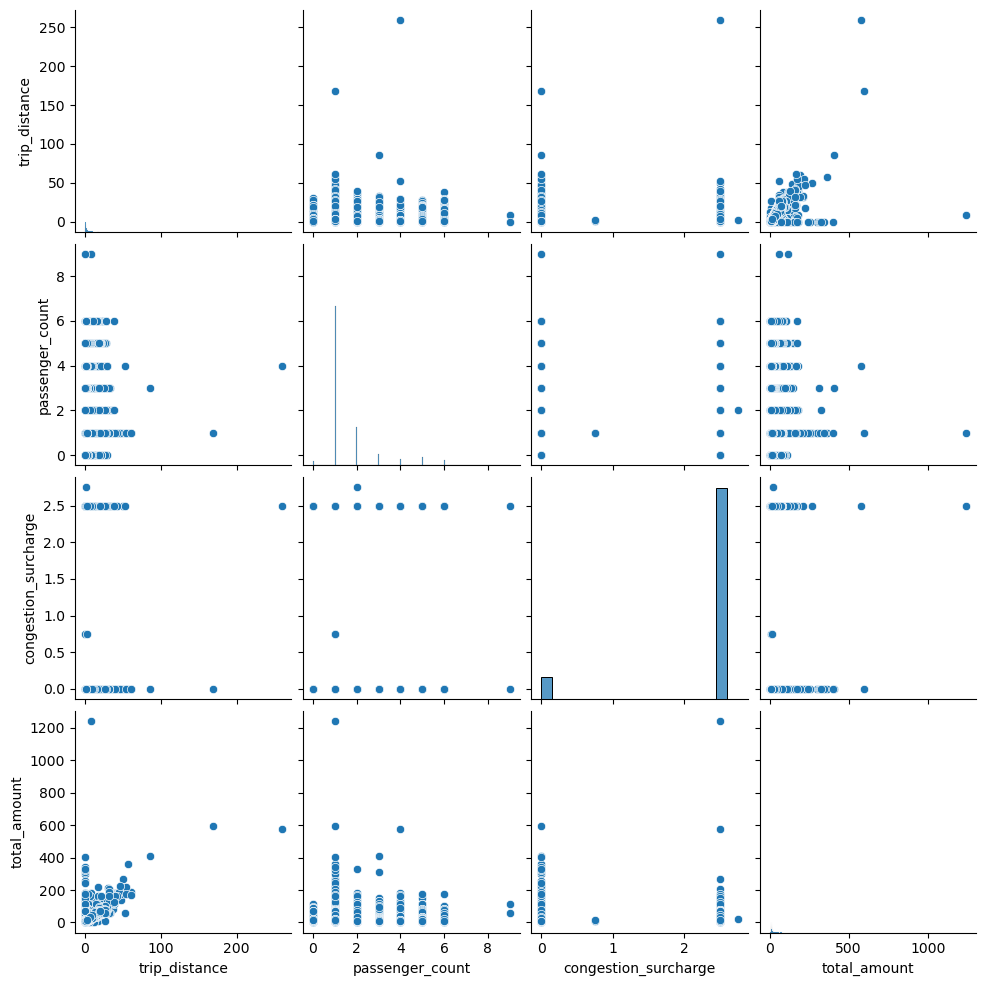

In [154]:
# Step 3: Check for linearity using scatterplots
sns.pairplot(df[['trip_distance', 'passenger_count', 'congestion_surcharge', 'total_amount']])
plt.show()

In [158]:
# Step 4: Fit the regression model
model = sm.OLS(y, X_with_const).fit()

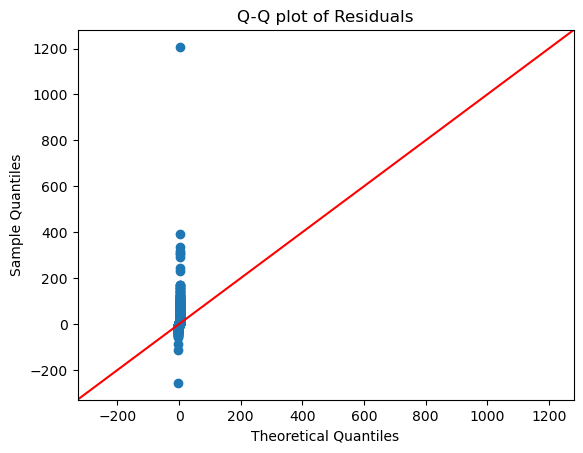

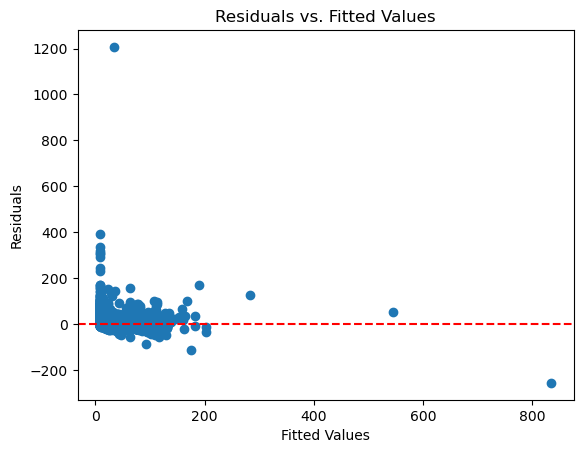

In [160]:
# Step 5: Check for assumptions

# 5.1 Residuals Normality (Q-Q plot)
residuals = model.resid
sm.qqplot(residuals, line='45')
plt.title("Q-Q plot of Residuals")
plt.show()

# 5.2 Homoscedasticity (Residuals vs. Fitted values plot)
fitted_values = model.fittedvalues
plt.scatter(fitted_values, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [162]:
# Step 6: Print model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           total_amount   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                 8.345e+04
Date:                Mon, 09 Dec 2024   Prob (F-statistic):               0.00
Time:                        03:57:50   Log-Likelihood:            -3.5478e+05
No. Observations:               99645   AIC:                         7.096e+05
Df Residuals:                   99641   BIC:                         7.096e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.1813 

**Interpretation of the OLS Regression Results:**

**Model Summary:**

* R-squared: 0.715 — This indicates that approximately 71.5% of the variation in total fare amount can be explained by the model, which includes trip distance, passenger count, and congestion surcharge.

* Adj. R-squared: 0.715 — Adjusted for the number of predictors, it still shows a strong explanatory power of the model.

* F-statistic: 83,450 — A very high F-statistic with a p-value < 0.05 indicates that the overall model is highly significant.

**Coefficients:**

* Intercept (const): 9.1813 — This is the predicted total fare amount when all independent variables (trip distance, passenger count, and congestion surcharge) are 0.
  
* Trip Distance: 3.1835 — For each additional unit of trip distance (e.g., 1 mile), the total fare is expected to increase by approximately $3.18, holding all other factors constant. This is statistically significant with a p-value < 0.05.

* Passenger Count: 0.0290 — For each additional passenger, the total fare is expected to increase by $0.029. However, this coefficient is not statistically significant (p-value = 0.203), meaning that passenger count does not have a strong impact on the total fare when accounting for other variables in the model.

* Congestion Surcharge: -0.1440 — For each unit increase in congestion surcharge, the total fare is expected to decrease by $0.144, which is statistically significant with a p-value < 0.05. This suggests that, contrary to expectations, a higher congestion surcharge results in a lower total fare, which could be due to specific conditions or data anomalies.

**Model Diagnostics:**

* Omnibus Test: A significant p-value indicates that the residuals deviate significantly from normality, which may suggest some non-normality in the residuals.

* Durbin-Watson: 2.00 — This value is close to 2, suggesting that there is no significant autocorrelation in the residuals.

* Jarque-Bera Test: The extremely high test statistic indicates that the residuals are far from normal, confirming that the model residuals are skewed and exhibit high kurtosis, suggesting outliers or heavy-tailed distributions.

**Key Insights:**

* Trip Distance is a significant predictor for total fare amount, with a strong positive relationship.

* Passenger Count does not significantly affect the total fare in this model, suggesting that other factors might be influencing fare amounts more strongly.

* Congestion Surcharge shows a negative relationship with the total fare, which is unexpected and might warrant further investigation, particularly for potential data anomalies or misinterpretations of the surcharge variable.